In [28]:
import h5py
import numpy as np
import matplotlib.pyplot as plt

In [29]:
GAMBIT_RANDOM = "FS_MSSM7atQ_random_gambit.hdf5"
GAMBIT_DIVER = "FS_MSSM7atQ_diver_gm2_gambit.hdf5"
MODELGEN = "SP_MSSM7atQ_random_modelgen.hdf5"
VERSION = 8

def open_scan(file_name: str, version: str = VERSION) -> h5py.File:
    """open a scan file and return the h5py File object"""
    file_path = f"../data/version-{version}/{file_name}"

    return h5py.File(file_path, "r")["MSSM"]

scan_modelgen = open_scan(MODELGEN)
scan_gambit_random = open_scan(GAMBIT_RANDOM)
scan_gambit_diver = open_scan(GAMBIT_DIVER)

In [30]:



mask = scan_gambit_random["LogLike_isvalid"][:] == 1
chi0_1_gr = scan_gambit_random["#MSSM_spectrum @SpecBit::get_MSSM_spectrum_as_map::~chi0_1 Pole_Mass"][mask]
chi0_2_gr = scan_gambit_random["#MSSM_spectrum @SpecBit::get_MSSM_spectrum_as_map::~chi0_2 Pole_Mass"][mask]
mask = scan_gambit_diver["LogLike_isvalid"][:] == 1
chi0_1_gd = scan_gambit_diver["#MSSM_spectrum @SpecBit::get_MSSM_spectrum_as_map::~chi0_1 Pole_Mass"][mask]
chi0_2_gd = scan_gambit_diver["#MSSM_spectrum @SpecBit::get_MSSM_spectrum_as_map::~chi0_2 Pole_Mass"][mask]
mask = scan_modelgen["SP_m_chi_10"][:] != -1
chi0_1_mg = scan_modelgen["SP_m_chi_10"][mask]
chi0_2_mg = scan_modelgen["SP_m_chi_20"][mask]



In [31]:
eff_gr = (len(chi0_1_gr) / len(scan_gambit_random["LogLike"][:])) * 100
eff_gd = (len(chi0_1_gd) / len(scan_gambit_diver["LogLike"][:])) * 100
eff_mg = (len(chi0_1_mg) / len(scan_modelgen["SP_m_chi_10"][:])) * 100

print(f"GAMBIT random: {len(chi0_1_gr)}/{len(scan_gambit_random["LogLike"][:])} {round(eff_gr, 2)}%")
print(f"GAMBIT diver: {len(chi0_1_gd)}/{len(scan_gambit_diver["LogLike"][:])} {round(eff_gd, 2)}%")
print(f"MODELGEN: {len(chi0_1_mg)}/{len(scan_modelgen["SP_m_chi_10"][:])} {round(eff_mg, 2)}%")

GAMBIT random: 150000/150000 100.0%
GAMBIT diver: 2077/30000 6.92%
MODELGEN: 572/30000 1.91%


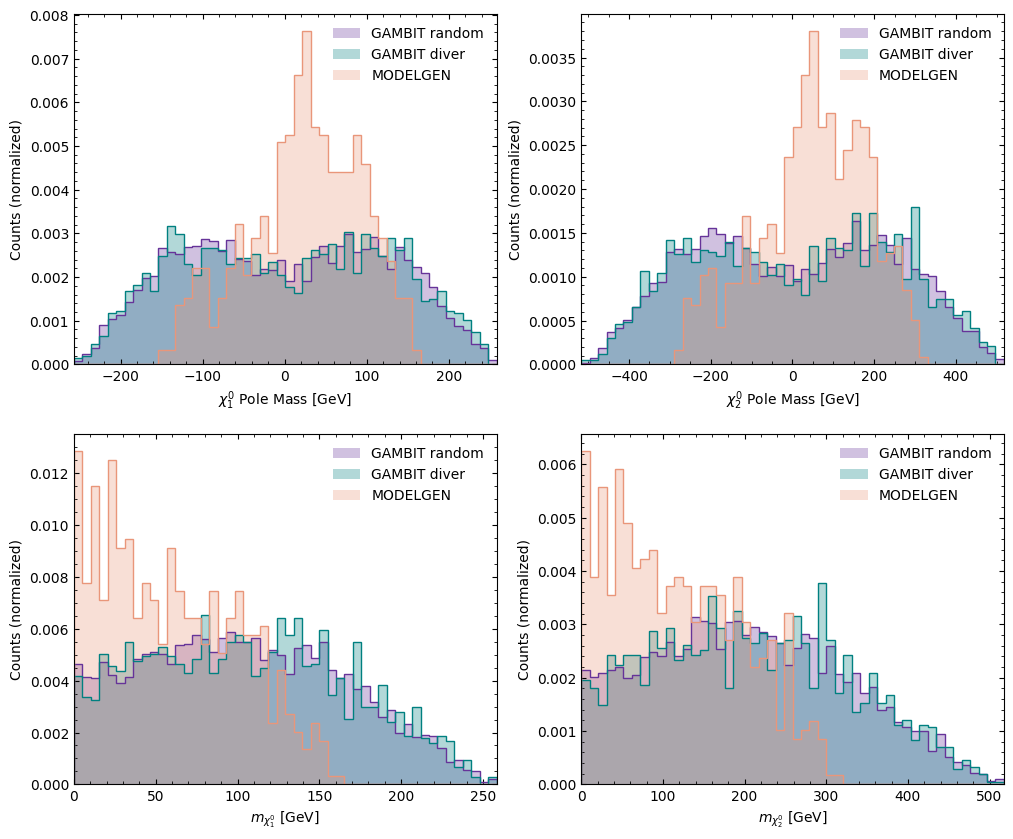

In [32]:
fig = plt.figure(figsize=(12,10))
ax1 = fig.add_subplot(221)
ax2 = fig.add_subplot(222)
ax3 = fig.add_subplot(223)
ax4 = fig.add_subplot(224)

hist_range1 = (
    min([np.min(chi0_1_gr), np.min(chi0_1_gd), np.min(chi0_1_mg)]),
    max([np.max(chi0_1_gr), np.max(chi0_1_gd), np.max(chi0_1_mg)]),
    )

hist_range2 = (
    min([np.min(chi0_2_gr), np.min(chi0_2_gd), np.min(chi0_2_mg)]),
    max([np.max(chi0_2_gr), np.max(chi0_2_gd), np.max(chi0_2_mg)]),
    )

ax1.hist(chi0_1_gr, bins=50,range=(hist_range1[0], hist_range1[1]), density=True, alpha=0.3, histtype='stepfilled', color='rebeccapurple', label='GAMBIT random')
ax1.hist(chi0_1_gd, bins=50,range=(hist_range1[0], hist_range1[1]), density=True, alpha=0.3, histtype='stepfilled', color='teal', label='GAMBIT diver')
ax1.hist(chi0_1_mg, bins=50,range=(hist_range1[0], hist_range1[1]), density=True, alpha=0.3, histtype='stepfilled', color='darksalmon', label='MODELGEN')
ax1.hist(chi0_1_gr, bins=50,range=(hist_range1[0], hist_range1[1]), density=True, histtype='step', color='rebeccapurple')
ax1.hist(chi0_1_gd, bins=50,range=(hist_range1[0], hist_range1[1]), density=True, histtype='step', color='teal')
ax1.hist(chi0_1_mg, bins=50,range=(hist_range1[0], hist_range1[1]), density=True, histtype='step', color='darksalmon')
ax1.set_xlim(hist_range1[0], hist_range1[1])
ax1.minorticks_on()
ax1.tick_params(axis='both', which='both', direction='in', top=True, right=True)
ax1.legend(frameon=False)
ax1.set_xlabel("$\\chi_1^0$ Pole Mass [GeV]")
ax1.set_ylabel("Counts (normalized)")

ax2.hist(chi0_2_gr, bins=50,range=(hist_range2[0], hist_range2[1]), density=True, alpha=0.3, histtype='stepfilled', color='rebeccapurple', label='GAMBIT random')
ax2.hist(chi0_2_gd, bins=50,range=(hist_range2[0], hist_range2[1]), density=True, alpha=0.3, histtype='stepfilled', color='teal', label='GAMBIT diver')
ax2.hist(chi0_2_mg, bins=50,range=(hist_range2[0], hist_range2[1]), density=True, alpha=0.3, histtype='stepfilled', color='darksalmon', label='MODELGEN')
ax2.hist(chi0_2_gr, bins=50,range=(hist_range2[0], hist_range2[1]), density=True, histtype='step', color='rebeccapurple')
ax2.hist(chi0_2_gd, bins=50,range=(hist_range2[0], hist_range2[1]), density=True, histtype='step', color='teal')
ax2.hist(chi0_2_mg, bins=50,range=(hist_range2[0], hist_range2[1]), density=True, histtype='step', color='darksalmon')
ax2.set_xlim(hist_range2[0], hist_range2[1])
ax2.minorticks_on()
ax2.tick_params(axis='both', which='both', direction='in', top=True, right=True)
ax2.legend(frameon=False)
ax2.set_xlabel("$\\chi_2^0$ Pole Mass [GeV]")
ax2.set_ylabel("Counts (normalized)")

ax3.hist(np.abs(chi0_1_gr), bins=50,range=(0, hist_range1[1]), density=True, alpha=0.3, histtype='stepfilled', color='rebeccapurple', label='GAMBIT random')
ax3.hist(np.abs(chi0_1_gd), bins=50,range=(0, hist_range1[1]), density=True, alpha=0.3, histtype='stepfilled', color='teal', label='GAMBIT diver')
ax3.hist(np.abs(chi0_1_mg), bins=50,range=(0, hist_range1[1]), density=True, alpha=0.3, histtype='stepfilled', color='darksalmon', label='MODELGEN')
ax3.hist(np.abs(chi0_1_gr), bins=50,range=(0, hist_range1[1]), density=True, histtype='step', color='rebeccapurple')
ax3.hist(np.abs(chi0_1_gd), bins=50,range=(0, hist_range1[1]), density=True, histtype='step', color='teal')
ax3.hist(np.abs(chi0_1_mg), bins=50,range=(0, hist_range1[1]), density=True, histtype='step', color='darksalmon')
ax3.set_xlim(0, hist_range1[1])
ax3.minorticks_on()
ax3.tick_params(axis='both', which='both', direction='in', top=True, right=True)
ax3.legend(frameon=False)
ax3.set_xlabel("$m_{\\chi_1^0}$ [GeV]")
ax3.set_ylabel("Counts (normalized)")

ax4.hist(np.abs(chi0_2_gr), bins=50,range=(0, hist_range2[1]), density=True, alpha=0.3, histtype='stepfilled', color='rebeccapurple', label='GAMBIT random')
ax4.hist(np.abs(chi0_2_gd), bins=50,range=(0, hist_range2[1]), density=True, alpha=0.3, histtype='stepfilled', color='teal', label='GAMBIT diver')
ax4.hist(np.abs(chi0_2_mg), bins=50,range=(0, hist_range2[1]), density=True, alpha=0.3, histtype='stepfilled', color='darksalmon', label='MODELGEN')
ax4.hist(np.abs(chi0_2_gr), bins=50,range=(0, hist_range2[1]), density=True, histtype='step', color='rebeccapurple')
ax4.hist(np.abs(chi0_2_gd), bins=50,range=(0, hist_range2[1]), density=True, histtype='step', color='teal')
ax4.hist(np.abs(chi0_2_mg), bins=50,range=(0, hist_range2[1]), density=True, histtype='step', color='darksalmon')
ax4.set_xlim(0, hist_range2[1])
ax4.minorticks_on()
ax4.tick_params(axis='both', which='both', direction='in', top=True, right=True)
ax4.legend(frameon=False)
ax4.set_xlabel("$m_{\\chi_2^0}$ [GeV]")
ax4.set_ylabel("Counts (normalized)")

fig.savefig(f"plots/neutralino-version-{VERSION}.png", dpi=1000)

plt.show()



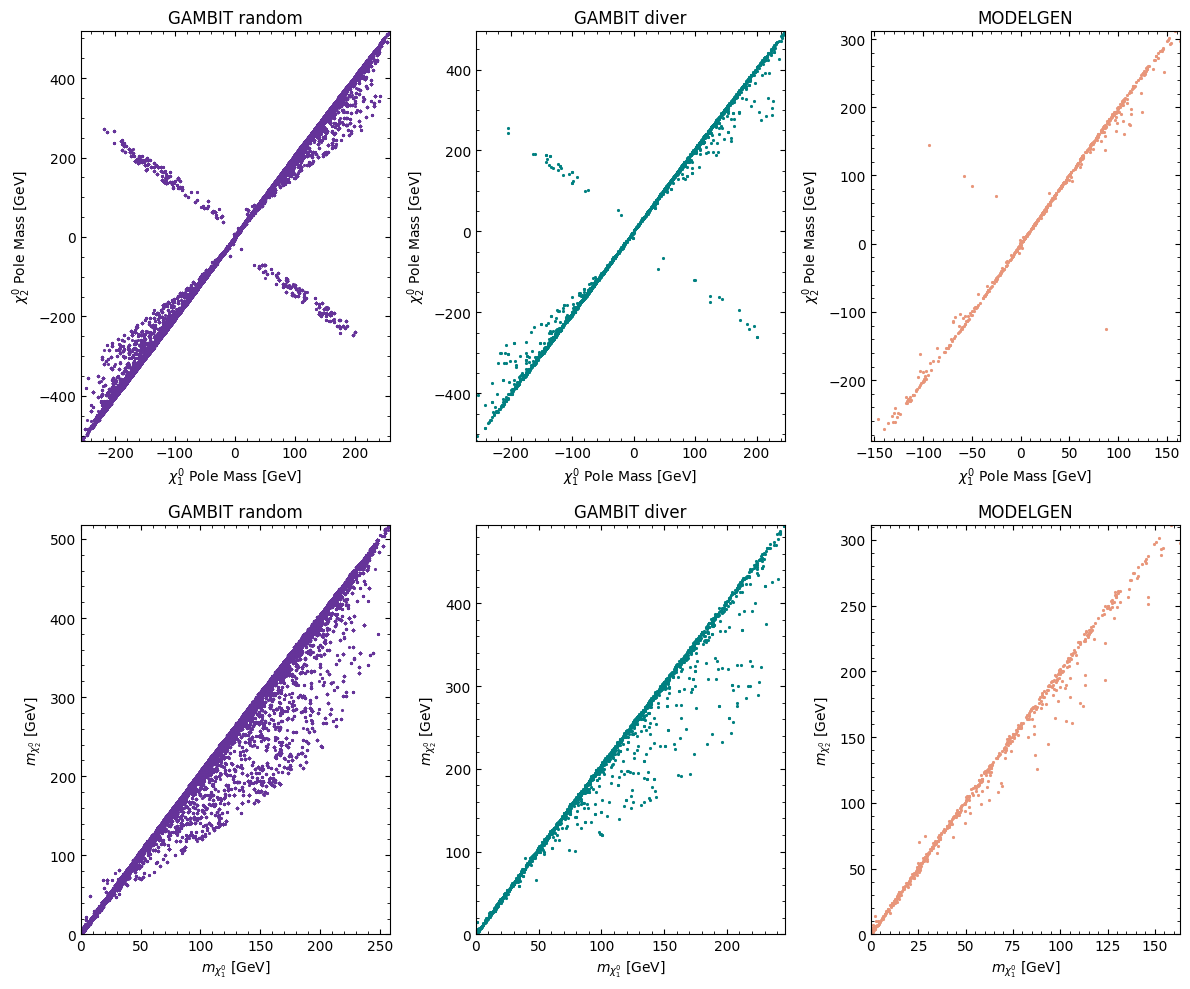

In [33]:
fig = plt.figure(figsize=(12, 10))
ax1 = fig.add_subplot(231)
ax2 = fig.add_subplot(232)
ax3 = fig.add_subplot(233)
ax4 = fig.add_subplot(234)
ax5 = fig.add_subplot(235)
ax6 = fig.add_subplot(236)


ax1.scatter(chi0_1_gr, chi0_2_gr, s=1.5, alpha=0.3, color='rebeccapurple', label='GAMBIT random')
ax1.scatter(chi0_1_gr, chi0_2_gr, s=1.5, alpha=1, facecolor=None, edgecolors='rebeccapurple', label='GAMBIT random')
ax1.set_title("GAMBIT random")
ax1.set_xlabel("$\\chi_1^0$ Pole Mass [GeV]")
ax1.set_ylabel("$\\chi_2^0$ Pole Mass [GeV]")
ax1.set_xlim(np.min(chi0_1_gr), np.max(chi0_1_gr))
ax1.set_ylim(np.min(chi0_2_gr), np.max(chi0_2_gr))
ax1.minorticks_on()
ax1.tick_params(axis='both', which='both', direction='in', top=True, right=True)

ax2.scatter(chi0_1_gd, chi0_2_gd, s=1.5, alpha=0.3, color='teal', label='GAMBIT diver')
ax2.scatter(chi0_1_gd, chi0_2_gd, s=1.5, alpha=1, facecolor=None, edgecolors='teal', label='GAMBIT diver')
ax2.set_title("GAMBIT diver")
ax2.set_xlabel("$\\chi_1^0$ Pole Mass [GeV]")
ax2.set_ylabel("$\\chi_2^0$ Pole Mass [GeV]")
ax2.set_xlim(np.min(chi0_1_gd), np.max(chi0_1_gd))
ax2.set_ylim(np.min(chi0_2_gd), np.max(chi0_2_gd))
ax2.minorticks_on()
ax2.tick_params(axis='both', which='both', direction='in', top=True, right=True)


ax3.scatter(chi0_1_mg, chi0_2_mg, s=1.5, alpha=0.3, color='darksalmon', label='MODELGEN')
ax3.scatter(chi0_1_mg, chi0_2_mg, s=1.5, alpha=1, facecolor=None, edgecolors='darksalmon', label='MODELGEN')
ax3.set_title("MODELGEN")
ax3.set_xlabel("$\\chi_1^0$ Pole Mass [GeV]")
ax3.set_ylabel("$\\chi_2^0$ Pole Mass [GeV]")
ax3.set_xlim(np.min(chi0_1_mg), np.max(chi0_1_mg))
ax3.set_ylim(np.min(chi0_2_mg), np.max(chi0_2_mg))
ax3.minorticks_on()
ax3.tick_params(axis='both', which='both', direction='in', top=True, right=True)

ax4.scatter(np.abs(chi0_1_gr), np.abs(chi0_2_gr), s=1.5, alpha=0.3, color='rebeccapurple', label='GAMBIT random')
ax4.scatter(np.abs(chi0_1_gr), np.abs(chi0_2_gr), s=1.5, alpha=1, facecolor=None, edgecolors='rebeccapurple', label='GAMBIT random')
ax4.set_title("GAMBIT random")
ax4.set_xlabel("$m_{\\chi_1^0}$ [GeV]")
ax4.set_ylabel("$m_{\\chi_2^0}$ [GeV]")
ax4.set_xlim(0, np.max(chi0_1_gr))
ax4.set_ylim(0, np.max(chi0_2_gr))
ax4.minorticks_on()
ax4.tick_params(axis='both', which='both', direction='in', top=True, right=True)

ax5.scatter(np.abs(chi0_1_gd), np.abs(chi0_2_gd), s=1.5, alpha=0.3, color='teal', label='GAMBIT diver')
ax5.scatter(np.abs(chi0_1_gd), np.abs(chi0_2_gd), s=1.5, alpha=1, facecolor=None, edgecolors='teal', label='GAMBIT diver')
ax5.set_title("GAMBIT diver")
ax5.set_xlabel("$m_{\\chi_1^0}$ [GeV]")
ax5.set_ylabel("$m_{\\chi_2^0}$ [GeV]")
ax5.set_xlim(0, np.max(chi0_1_gd))
ax5.set_ylim(0, np.max(chi0_2_gd))
ax5.minorticks_on()
ax5.tick_params(axis='both', which='both', direction='in', top=True, right=True)


ax6.scatter(np.abs(chi0_1_mg), np.abs(chi0_2_mg), s=1.5, alpha=0.3, color='darksalmon', label='MODELGEN')
ax6.scatter(np.abs(chi0_1_mg), np.abs(chi0_2_mg), s=1.5, alpha=1, facecolor=None, edgecolors='darksalmon', label='MODELGEN')
ax6.set_title("MODELGEN")
ax6.set_xlabel("$m_{\\chi_1^0}$ [GeV]")
ax6.set_ylabel("$m_{\\chi_2^0}$ [GeV]")
ax6.set_xlim(0, np.max(chi0_1_mg))
ax6.set_ylim(0, np.max(chi0_2_mg))
ax6.minorticks_on()
ax6.tick_params(axis='both', which='both', direction='in', top=True, right=True)


fig.tight_layout()

plt.show()

